In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

c:\Users\Hedi\anaconda3\envs\nlp_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
print(sys.executable)

c:\Users\Hedi\anaconda3\envs\nlp_gpu\python.exe


In [3]:
fakeA = pd.read_csv("Fake.csv")
trueA = pd.read_csv("True.csv")

fakeA["label"] = 1
trueA["label"] = 0

A = pd.concat([fakeA[["text","label"]], trueA[["text","label"]]], ignore_index=True)
A = A.dropna().sample(frac=1, random_state=42).reset_index(drop=True)

print("A columns:", A.columns.tolist())
print("A size:", len(A))
print(A["label"].value_counts())

A columns: ['text', 'label']
A size: 44898
label
1    23481
0    21417
Name: count, dtype: int64


In [4]:
B_raw = pd.read_excel("fake_new_dataset.xlsx")

# on utilise tes colonnes:
B = B_raw[["text","label"]].copy()
B = B.dropna().sample(frac=1, random_state=42).reset_index(drop=True)

print("\nB size:", len(B))
print("B label counts:\n", B["label"].value_counts())



B size: 3119
B label counts:
 label
1    2061
0    1058
Name: count, dtype: int64


In [27]:
A_train, A_test = train_test_split(A, test_size=0.2, stratify=A["label"], random_state=42)
B_pool, B_test  = train_test_split(B, test_size=0.2, stratify=B["label"], random_state=42)

A_train = A_train.reset_index(drop=True)
A_test  = A_test.reset_index(drop=True)
B_pool  = B_pool.reset_index(drop=True)
B_test  = B_test.reset_index(drop=True)

print("\nSplits:")
print("A_train:", len(A_train), "A_test:", len(A_test))
print("B_pool :", len(B_pool),  "B_test:", len(B_test))
print(A_train["label"].value_counts())
print(A_test["label"].value_counts())
print(B_pool["label"].value_counts())
print(B_test["label"].value_counts())


Splits:
A_train: 35918 A_test: 8980
B_pool : 2495 B_test: 624
label
1    18785
0    17133
Name: count, dtype: int64
label
1    4696
0    4284
Name: count, dtype: int64
label
1    1649
0     846
Name: count, dtype: int64
label
1    412
0    212
Name: count, dtype: int64


In [6]:
class NewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=64):
        self.texts = df["text"].astype(str).tolist()
        self.labels = df["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

In [8]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

train_dataset = NewsDataset(A_train, tokenizer, max_length=64)
atest_dataset  = NewsDataset(A_test, tokenizer, max_length=64)
btest_dataset  = NewsDataset(B_test, tokenizer, max_length=64)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:

training_args = TrainingArguments(
    output_dir="./bert_baseline",
    eval_strategy="no",
    per_device_train_batch_size=16,
    num_train_epochs=1,
    max_steps=200,
    learning_rate=1e-5,
    save_strategy="no",
    report_to="none",
    fp16=True
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=atest_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

C:\Users\Hedi\AppData\Local\Temp\ipykernel_14940\1013394474.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [10]:
import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

torch: 2.5.1
cuda available: True
gpu: NVIDIA GeForce RTX 4070 Laptop GPU


In [11]:
trainer.train()


Step,Training Loss


TrainOutput(global_step=200, training_loss=0.1327859115600586, metrics={'train_runtime': 104.4218, 'train_samples_per_second': 30.645, 'train_steps_per_second': 1.915, 'total_flos': 105244422144000.0, 'train_loss': 0.1327859115600586, 'epoch': 0.08908685968819599})

In [12]:
print("Baseline A → A_test")
res_AA = trainer.evaluate(atest_dataset)
print(res_AA)

print("\nBaseline A → B_test (COVID)")
res_AB = trainer.evaluate(btest_dataset)
print(res_AB)

Baseline A → A_test


{'eval_loss': 0.010728713124990463, 'eval_accuracy': 0.9992204899777283, 'eval_f1': 0.999254764186096, 'eval_runtime': 259.9805, 'eval_samples_per_second': 34.541, 'eval_steps_per_second': 4.32, 'epoch': 0.08908685968819599}

Baseline A → B_test (COVID)
{'eval_loss': 1.46645987033844, 'eval_accuracy': 0.657051282051282, 'eval_f1': 0.7893700787401575, 'eval_runtime': 22.6153, 'eval_samples_per_second': 27.592, 'eval_steps_per_second': 3.449, 'epoch': 0.08908685968819599}


In [13]:
baseline_results = {
    "A_to_A_accuracy": res_AA["eval_accuracy"],
    "A_to_A_f1": res_AA["eval_f1"],
    "A_to_B_accuracy": res_AB["eval_accuracy"],
    "A_to_B_f1": res_AB["eval_f1"],
}

baseline_results


{'A_to_A_accuracy': 0.9992204899777283,
 'A_to_A_f1': 0.999254764186096,
 'A_to_B_accuracy': 0.657051282051282,
 'A_to_B_f1': 0.7893700787401575}

In [14]:
budget = 0.01  #   je vais tester le budget à 1%
k = int(len(B_pool) * budget)
print("Budget:", budget, "=> k =", k)

Budget: 0.01 => k = 24


In [15]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments, set_seed
import numpy as np
import pandas as pd

def make_step_args(base_args, out_dir_suffix):
    # 1 epoch par checkpoint (continuous)
    return TrainingArguments(
        output_dir=f"{base_args.output_dir}_{out_dir_suffix}",
        evaluation_strategy="no",
        per_device_train_batch_size=base_args.per_device_train_batch_size,
        per_device_eval_batch_size=base_args.per_device_eval_batch_size,
        learning_rate=base_args.learning_rate,
        num_train_epochs=1,          # ✅ 1 epoch par checkpoint
        save_strategy="no",
        report_to="none",
        fp16=getattr(base_args, "fp16", False),
        logging_steps=getattr(base_args, "logging_steps", 200),
    )


Random + incremental method

In [16]:
def run_incremental_continuous_random(seed, budgets, max_length=128):
    set_seed(seed)

    pool = B_pool.copy().reset_index(drop=True)
    selected_total = pd.DataFrame(columns=pool.columns)

    # modèle initial
    model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

    # baseline training sur A
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=NewsDataset(A_train, tokenizer, max_length=max_length),
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )
    trainer.train()

    results = []
    prev_k = 0

    for b in budgets:
        target_k = int(len(B_pool) * b)
        delta_k = target_k - prev_k
        prev_k = target_k

        # selection incremtal random
        idx = np.random.choice(len(pool), size=delta_k, replace=False)
        new_selected = pool.iloc[idx].copy()
        selected_total = pd.concat([selected_total, new_selected], ignore_index=True)
        pool = pool.drop(index=idx).reset_index(drop=True)

        train_mix = pd.concat([A_train, selected_total], ignore_index=True)\
                      .sample(frac=1, random_state=seed).reset_index(drop=True)

        train_ds = NewsDataset(train_mix, tokenizer, max_length=max_length)

        # continuous training process not from the scratch
        trainer = Trainer(
            model=trainer.model,   # ⚠️ on continue
            args=training_args,
            train_dataset=train_ds,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics
        )
        trainer.train()

        score = trainer.evaluate(btest_dataset)

        results.append({
            "seed": seed,
            "strategy": "Random",
            "budget": b,
            "k": target_k,
            "accuracy": score["eval_accuracy"],
            "f1": score["eval_f1"]
        })

    return pd.DataFrame(results)


In [17]:
def predict_proba(model, tokenizer, texts, max_length=128, batch_size=32):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()
    model.to(device)

    all_probs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )
            enc = {k: v.to(device) for k, v in enc.items()}

            out = model(**enc)
            probs = torch.softmax(out.logits, dim=1).detach().cpu().numpy()
            all_probs.append(probs)

    return np.vstack(all_probs)

def entropy_from_probs(probs):
    eps = 1e-12
    return -np.sum(probs * np.log(probs + eps), axis=1)

Entropy + incremetal Selection + continous process

In [18]:
def run_incremental_continuous_entropy(seed, budgets, max_length=128):
    set_seed(seed)

    pool = B_pool.copy().reset_index(drop=True)
    selected_total = pd.DataFrame(columns=pool.columns)

    model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=NewsDataset(A_train, tokenizer, max_length=max_length),
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )
    trainer.train()

    results = []
    prev_k = 0

    for b in budgets:
        target_k = int(len(B_pool) * b)
        delta_k = target_k - prev_k
        prev_k = target_k

        # selection incremental par entropie 
        texts_pool = pool["text"].astype(str).tolist()
        probs_pool = predict_proba(trainer.model, tokenizer, texts_pool, max_length=max_length, batch_size=32)
        ent_pool = entropy_from_probs(probs_pool)

        idx = np.argsort(-ent_pool)[:delta_k]

        new_selected = pool.iloc[idx].copy()
        selected_total = pd.concat([selected_total, new_selected], ignore_index=True)
        pool = pool.drop(index=idx).reset_index(drop=True)

        train_mix = pd.concat([A_train, selected_total], ignore_index=True)\
                      .sample(frac=1, random_state=seed).reset_index(drop=True)

        train_ds = NewsDataset(train_mix, tokenizer, max_length=max_length)

        # continuous training process not from the scratch 
        trainer = Trainer(
            model=trainer.model,
            args=training_args,
            train_dataset=train_ds,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics
        )
        trainer.train()

        score = trainer.evaluate(btest_dataset)

        results.append({
            "seed": seed,
            "strategy": "Entropy",
            "budget": b,
            "k": target_k,
            "accuracy": score["eval_accuracy"],
            "f1": score["eval_f1"]
        })

    return pd.DataFrame(results)


lancer l'entrainement avec des methodes active learning 

In [19]:
seeds = [0,1,2,3,4]
budgets = [0.10, 0.20, 0.30, 0.50, 0.60]
df_random =[]
df_entropy = []
df_all = []

for s in seeds:
    print("RUN", s, "Random")
    df_random.append(run_incremental_continuous_random(s, budgets))

    print("RUN", s, "Entropy")
    df_entropy.append(run_incremental_continuous_entropy(s, budgets))



RUN 0 Random


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Hedi\AppData\Local\Temp\ipykernel_14940\2761457088.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


C:\Users\Hedi\AppData\Local\Temp\ipykernel_14940\2761457088.py:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


...

C:\Users\Hedi\AppData\Local\Temp\ipykernel_14940\2761457088.py:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


C:\Users\Hedi\AppData\Local\Temp\ipykernel_14940\2761457088.py:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


KeyboardInterrupt: 

In [ ]:
df_random = pd.concat(df_random, ignore_index=True)
df_entropy = pd.concat(df_entropy, ignore_index=True)

df_all = pd.concat([df_random, df_entropy], ignore_index=True)
df_all.head()


,seed,strategy,budget,k,accuracy,f1
0,0,Random,0.1,249,0.661859,0.790882
1,0,Random,0.2,499,0.665064,0.796098
2,0,Random,0.3,748,0.665064,0.796098
3,0,Random,0.5,1247,0.671474,0.798030
4,0,Random,0.6,1497,0.687500,0.805583


: 

: 

: 

Cluster based Sampling (diversty)

In [20]:
import numpy as np
import torch

def get_cls_embeddings(model, tokenizer, texts, max_length=128, batch_size=32):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()
    model.to(device)

    embs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )
            enc = {k: v.to(device) for k, v in enc.items()}

            # BertForSequenceClassification => model.bert existe
            out = model.bert(**enc)
            cls = out.last_hidden_state[:, 0, :].detach().cpu().numpy()  # [bs, hidden]
            embs.append(cls)

    return np.vstack(embs)


In [21]:
from sklearn.cluster import KMeans
def run_incremental_continuous_cluster(seed, budgets, max_length=128, batch_size=32):
    set_seed(seed)

    pool = B_pool.copy().reset_index(drop=True)
    selected_total = pd.DataFrame(columns=pool.columns)

    model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=NewsDataset(A_train, tokenizer, max_length=max_length),
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )
    trainer.train()

    results = []
    prev_k = 0

    for b in budgets:
        target_k = int(len(B_pool) * b)
        delta_k = target_k - prev_k
        prev_k = target_k

        if delta_k <= 0 or len(pool) == 0:
            continue

        # 🔵 selection incremental par clustering (diversity)
        texts_pool = pool["text"].astype(str).tolist()

        # embeddings CLS du pool restant (avec le modèle courant)
        embs = get_cls_embeddings(
            trainer.model, tokenizer, texts_pool,
            max_length=max_length, batch_size=batch_size
        )

        k = min(delta_k, len(texts_pool))
        if k == 0:
            continue

        # ✅ n_init=10 pour compatibilité (au lieu de "auto")
        km = KMeans(n_clusters=k, random_state=seed, n_init=10).fit(embs)

        centers = km.cluster_centers_
        labels = km.labels_

        idx_local = []
        for c in range(k):
            members = np.where(labels == c)[0]
            if len(members) == 0:
                continue
            dists = np.linalg.norm(embs[members] - centers[c], axis=1)
            idx_local.append(members[np.argmin(dists)])

        # fallback si on a moins de k points (clusters vides)
        idx_local = list(dict.fromkeys(idx_local))  # unique en gardant l'ordre
        if len(idx_local) < k:
            remaining = np.setdiff1d(np.arange(len(texts_pool)), np.array(idx_local, dtype=int))
            need = k - len(idx_local)
            idx_local.extend(list(remaining[:need]))

        idx = np.array(idx_local[:k], dtype=int)

        # update selected / pool
        new_selected = pool.iloc[idx].copy()
        selected_total = pd.concat([selected_total, new_selected], ignore_index=True)
        pool = pool.drop(index=idx).reset_index(drop=True)

        # train cumulatif
        train_mix = (
            pd.concat([A_train, selected_total], ignore_index=True)
              .sample(frac=1, random_state=seed)
              .reset_index(drop=True)
        )
        train_ds = NewsDataset(train_mix, tokenizer, max_length=max_length)

        # 🔵 continuous training (on garde les poids)
        trainer = Trainer(
            model=trainer.model,
            args=training_args,
            train_dataset=train_ds,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics
        )
        trainer.train()

        score = trainer.evaluate(btest_dataset)

        results.append({
            "seed": seed,
            "strategy": "Cluster-based",
            "budget": b,
            "k": target_k,
            "accuracy": score["eval_accuracy"],
            "f1": score["eval_f1"]
        })

    return pd.DataFrame(results)


In [ ]:
seeds = [0,1,2,3,4]
budgets = [0.10, 0.20, 0.30, 0.50, 0.60]
dfs_cluster = []
for s in seeds:
    print("RUN", s, "Cluster-based")
    dfs_cluster.append(run_incremental_continuous_cluster(s, budgets))

df_cluster = pd.concat(dfs_cluster, ignore_index=True)
df_cluster.head()
df_all = pd.concat([df_random, df_entropy, df_cluster], ignore_index=True)



RUN 0 Cluster-based


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Hedi\AppData\Local\Temp\ipykernel_14548\1974792162.py:10: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


C:\Users\Hedi\AppData\Local\Temp\ipykernel_14548\1974792162.py:80: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


...

c:\Users\Hedi\anaconda3\envs\nlp_gpu\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\Hedi\AppData\Local\Temp\ipykernel_14548\1974792162.py:80: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


: 

: 

: 

In [22]:
df_all.to_csv("df_all.csv", index=False)

AttributeError: 'list' object has no attribute 'to_csv'

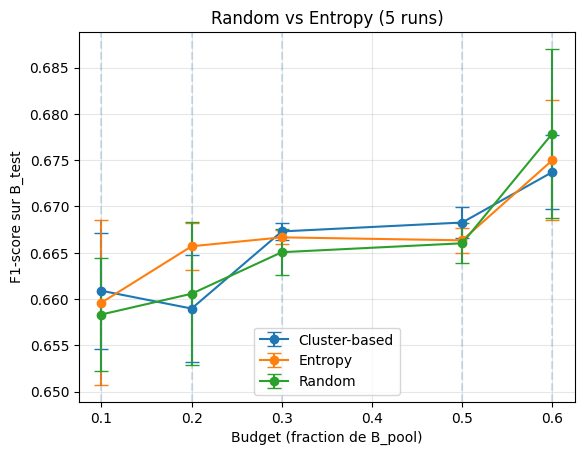

: 

: 

: 

In [ ]:
summary = (
    df_all.groupby(["strategy","budget"])
          .agg(acc_mean=("accuracy","mean"), acc_std=("accuracy","std"),
               f1_mean=("f1","mean"), f1_std=("f1","std"))
          .reset_index()
)

import matplotlib.pyplot as plt

for strat in summary["strategy"].unique():
    sub = summary[summary["strategy"] == strat]
    plt.errorbar(sub["budget"], sub["acc_mean"], yerr=sub["f1_std"],
                 marker="o", capsize=5, label=strat)

for b in budgets:
    plt.axvline(b, linestyle="--", alpha=0.2)

plt.xlabel("Budget (fraction de B_pool)")
plt.ylabel("F1-score sur B_test")
plt.title("Random vs Entropy (5 runs)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Mixed method

In [23]:
def run_incremental_continuous_mixed(seed, budgets, max_length=128, batch_size=32):
    set_seed(seed)

    pool = B_pool.copy().reset_index(drop=True)
    selected_total = pd.DataFrame(columns=pool.columns)

    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased", num_labels=2
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=NewsDataset(A_train, tokenizer, max_length=max_length),
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )
    trainer.train()

    results = []
    prev_k = 0

    for b in budgets:

        target_k = int(len(B_pool) * b)
        delta_k = target_k - prev_k
        prev_k = target_k

        if delta_k <= 0 or len(pool) == 0:
            continue

        texts_pool = pool["text"].astype(str).tolist()

        # ---------- ENTROPY ----------
        probs_pool = predict_proba(
            trainer.model,
            tokenizer,
            texts_pool,
            max_length=max_length,
            batch_size=batch_size
        )

        ent = entropy_from_probs(probs_pool)

        k_half = delta_k // 2

        idx_entropy = np.argsort(-ent)[:k_half]

        # ---------- CLUSTER ----------
        embs = get_cls_embeddings(
            trainer.model,
            tokenizer,
            texts_pool,
            max_length=max_length,
            batch_size=batch_size
        )

        k_cluster = delta_k - k_half
        k_cluster = min(k_cluster, len(texts_pool))

        km = KMeans(n_clusters=k_cluster, random_state=seed, n_init=10).fit(embs)

        centers = km.cluster_centers_
        labels = km.labels_

        idx_cluster = []

        for c in range(k_cluster):
            members = np.where(labels == c)[0]
            if len(members) == 0:
                continue
            dists = np.linalg.norm(
                embs[members] - centers[c], axis=1
            )
            idx_cluster.append(
                members[np.argmin(dists)]
            )

        idx = np.unique(
            np.concatenate([idx_entropy, idx_cluster])
        )

        new_selected = pool.iloc[idx].copy()

        selected_total = pd.concat(
            [selected_total, new_selected],
            ignore_index=True
        )

        pool = pool.drop(index=idx).reset_index(drop=True)

        train_mix = pd.concat(
            [A_train, selected_total],
            ignore_index=True
        ).sample(frac=1, random_state=seed)

        train_ds = NewsDataset(
            train_mix,
            tokenizer,
            max_length=max_length
        )

        trainer = Trainer(
            model=trainer.model,
            args=training_args,
            train_dataset=train_ds,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics
        )

        trainer.train()

        score = trainer.evaluate(btest_dataset)

        results.append({
            "seed": seed,
            "strategy": "Mixed",
            "budget": b,
            "k": target_k,
            "accuracy": score["eval_accuracy"],
            "f1": score["eval_f1"]
        })

    return pd.DataFrame(results)

In [26]:
seeds = [0,1,2,3,4]
budgets = [0.10, 0.20, 0.30, 0.50, 0.60]
dfs_mixed = []

for s in seeds:
    print("RUN", s, "Mixed")
    dfs_mixed.append(
        run_incremental_continuous_mixed(s, budgets)
    )

df_mixed = pd.concat(dfs_mixed, ignore_index=True)

df_mixed.to_csv("results_mixed.csv", index=False)

RUN 0 Mixed


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Hedi\AppData\Local\Temp\ipykernel_14940\1037758232.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


C:\Users\Hedi\AppData\Local\Temp\ipykernel_14940\1037758232.py:103: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


...

Step,Training Loss


C:\Users\Hedi\AppData\Local\Temp\ipykernel_14940\1037758232.py:103: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


c:\Users\Hedi\anaconda3\envs\nlp_gpu\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Hedi\AppData\Local\Temp\ipykernel_14940\1037758232.py:103: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


['Random' 'Entropy' 'Cluster-based' 'Mixed']
['Cluster-based' 'Entropy' 'Mixed' 'Random']


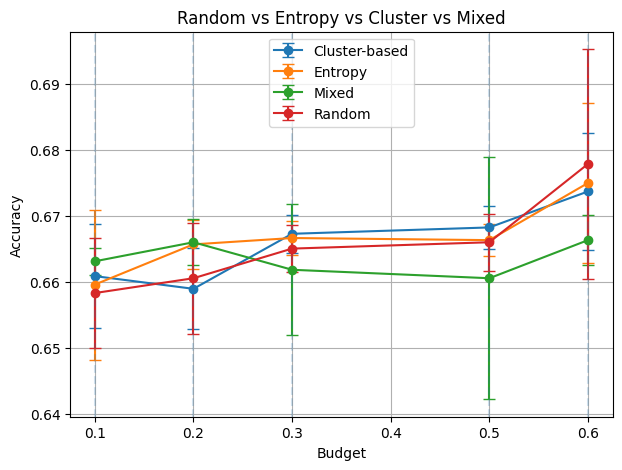

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("df_all.csv")

# ---- nettoyage important ----
df["strategy"] = df["strategy"].str.strip()

print(df["strategy"].unique())  # DEBUG

# ---- aggregation ----
summary = (
    df.groupby(["strategy", "budget"])
    .agg(
        acc_mean=("accuracy", "mean"),
        acc_std=("accuracy", "std"),
    )
    .reset_index()
)

print(summary["strategy"].unique())  # DEBUG

budgets = sorted(summary["budget"].unique())

plt.figure(figsize=(7,5))

for strat in summary["strategy"].unique():
    sub = summary[summary["strategy"] == strat]

    plt.errorbar(
        sub["budget"],
        sub["acc_mean"],
        yerr=sub["acc_std"],
        marker="o",
        capsize=4,
        label=strat
    )

for b in budgets:
    plt.axvline(b, linestyle="--", alpha=0.2)

plt.xlabel("Budget")
plt.ylabel("Accuracy")
plt.title("Random vs Entropy vs Cluster vs Mixed")
plt.legend()
plt.grid(True)
plt.show()